In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("traffic_cleaned.csv")

df['date'] = pd.to_datetime(df['date'])

print("Dataset shape:", df.shape)

Dataset shape: (122567, 9)


In [2]:
total_events = len(df)

pageviews = (df['event'] == 'pageview').sum()
clicks = (df['event'] == 'click').sum()
previews = (df['event'] == 'preview').sum()

pageview_click_rate = (clicks / pageviews) * 100
pageview_preview_rate = (previews / pageviews) * 100

kpis = {
    'Total Events': total_events,
    'Pageviews': pageviews,
    'Clicks': clicks,
    'Previews': previews,
    'Pageview → Click Rate': pageview_click_rate,
    'Pageview → Preview Rate': pageview_preview_rate,
    'Countries': df['country'].nunique(),
    'Cities': df['city'].nunique(),
    'Artists': df['artist'].nunique(),
    'Tracks': df['track'].nunique(),
    'Links': df['linkid'].nunique()
}

kpis

{'Total Events': 122567,
 'Pageviews': np.int64(73360),
 'Clicks': np.int64(32499),
 'Previews': np.int64(16708),
 'Pageview → Click Rate': np.float64(44.30070883315158),
 'Pageview → Preview Rate': np.float64(22.77535441657579),
 'Countries': 211,
 'Cities': 11993,
 'Artists': 2419,
 'Tracks': 3562,
 'Links': 3839}

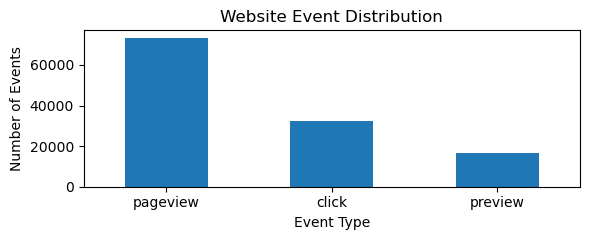

In [5]:
event_counts = df['event'].value_counts()

plt.figure(figsize=(6,2.5))

event_counts.plot(kind='bar')

plt.title('Website Event Distribution')
plt.xlabel('Event Type')
plt.ylabel('Number of Events')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

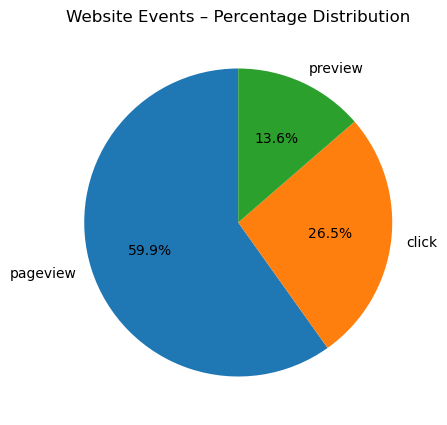

In [10]:
plt.figure(figsize=(5,5))

plt.pie(
    event_counts.values,
    labels=event_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Website Events – Percentage Distribution')

plt.show()

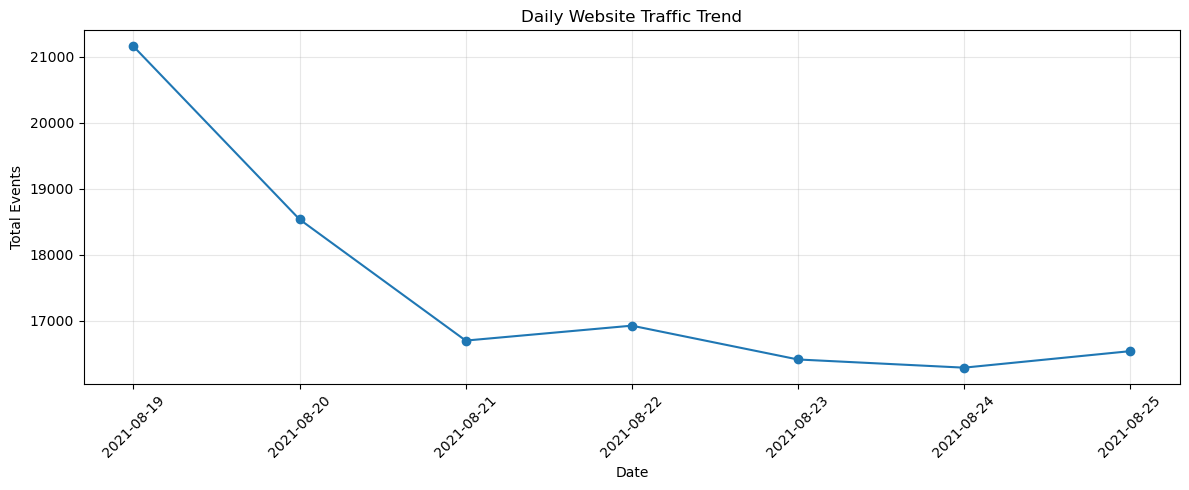

In [11]:
daily_traffic = df.groupby('date').size()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_traffic.index,
    daily_traffic.values,
    marker='o'
)

plt.title('Daily Website Traffic Trend')
plt.xlabel('Date')
plt.ylabel('Total Events')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

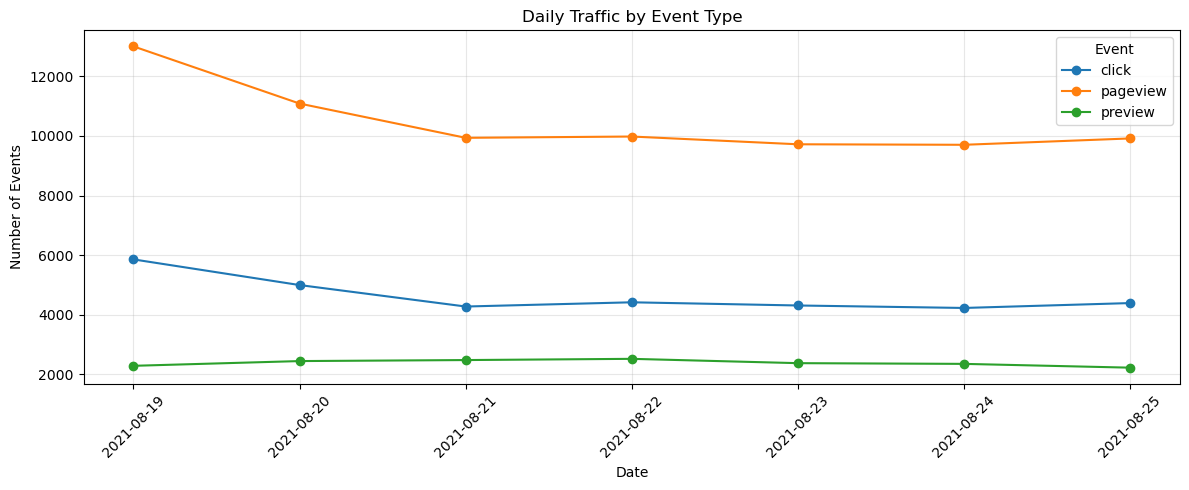

In [13]:
daily_event = (
    df.groupby(['date', 'event'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(12, 5))

for event in daily_event.columns:
    plt.plot(
        daily_event.index,
        daily_event[event],
        marker='o',
        label=event
    )

plt.title('Daily Traffic by Event Type')
plt.xlabel('Date')
plt.ylabel('Number of Events')

plt.xticks(rotation=45)
plt.legend(title='Event')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

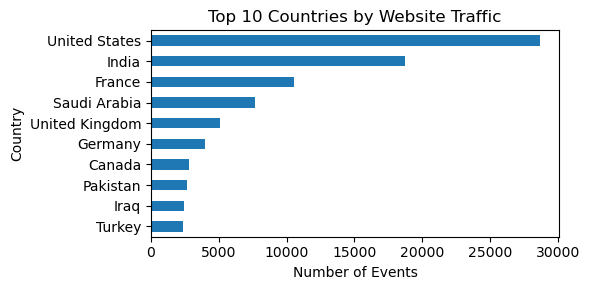

In [17]:
country_traffic = df['country'].value_counts().head(10)

plt.figure(figsize=(6, 3))

country_traffic.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Website Traffic')
plt.xlabel('Number of Events')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

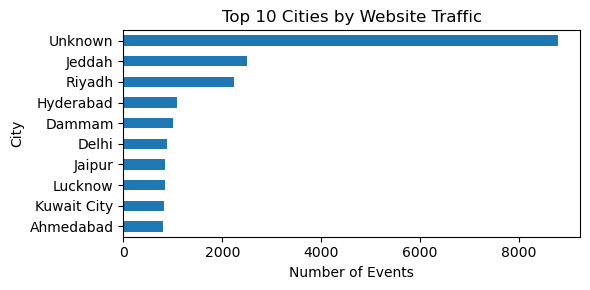

In [19]:
city_traffic = df['city'].value_counts().head(10)

plt.figure(figsize=(6,3))

city_traffic.sort_values().plot(kind='barh')

plt.title('Top 10 Cities by Website Traffic')
plt.xlabel('Number of Events')
plt.ylabel('City')

plt.tight_layout()
plt.show()

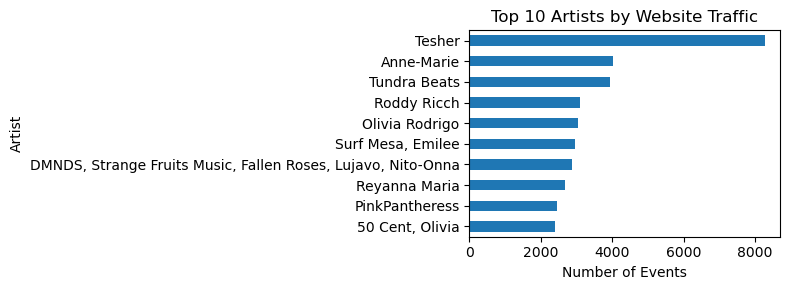

In [22]:
artist_traffic = df['artist'].value_counts().head(10)

plt.figure(figsize=(8,3))

artist_traffic.sort_values().plot(kind='barh')

plt.title('Top 10 Artists by Website Traffic')
plt.xlabel('Number of Events')
plt.ylabel('Artist')

plt.tight_layout()
plt.show()

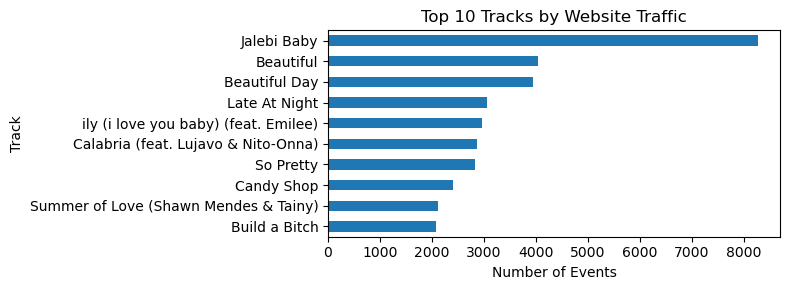

In [23]:
track_traffic = df['track'].value_counts().head(10)

plt.figure(figsize=(8,3))

track_traffic.sort_values().plot(kind='barh')

plt.title('Top 10 Tracks by Website Traffic')
plt.xlabel('Number of Events')
plt.ylabel('Track')

plt.tight_layout()
plt.show()

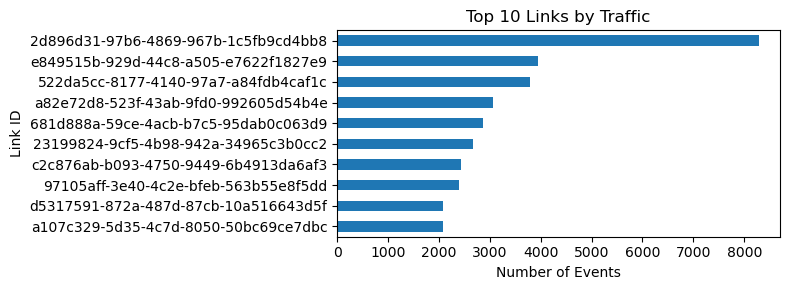

In [24]:
link_traffic = df['linkid'].value_counts().head(10)

plt.figure(figsize=(8,3))

link_traffic.sort_values().plot(kind='barh')

plt.title('Top 10 Links by Traffic')
plt.xlabel('Number of Events')
plt.ylabel('Link ID')

plt.tight_layout()
plt.show()

In [25]:
country_event = pd.crosstab(
    df['country'],
    df['event']
)

top_countries = df['country'].value_counts().head(10).index

country_event_top = country_event.loc[top_countries]

country_event_top

event,click,pageview,preview
country,,,
United States,8446,18131,2087
India,5360,10565,2764
France,2792,6181,1592
Saudi Arabia,1976,3712,1994
United Kingdom,1307,3218,570
Germany,1030,2585,402
Canada,840,1702,242
Pakistan,754,1382,497
Iraq,567,1285,592


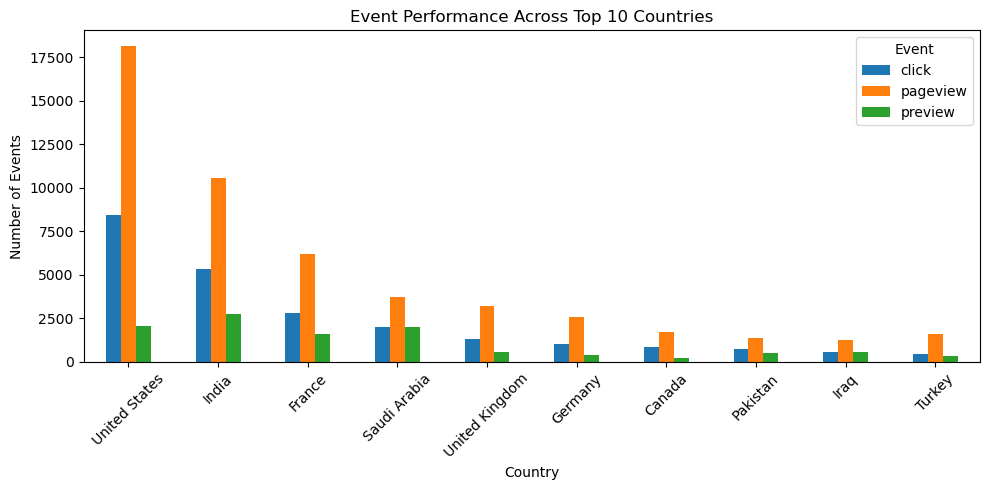

In [29]:
country_event_top.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Event Performance Across Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)

plt.legend(title='Event')

plt.tight_layout()
plt.show()

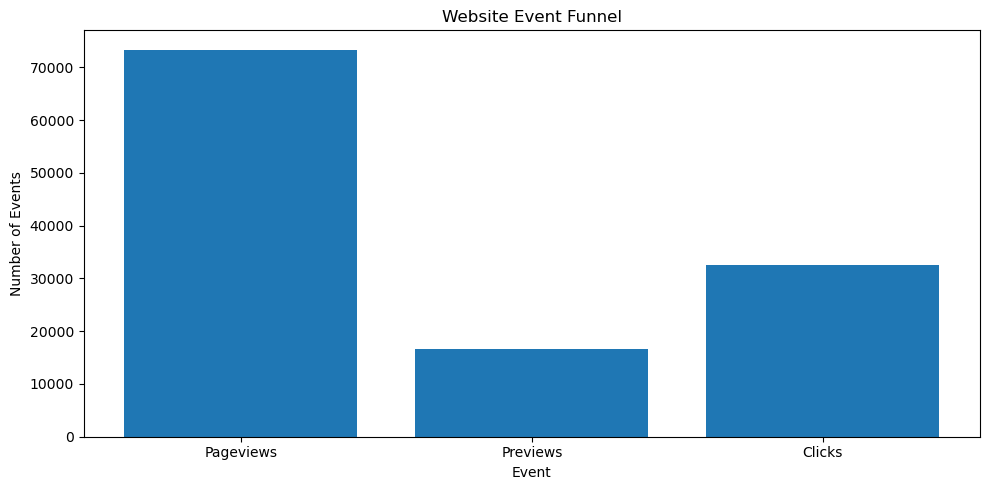

In [32]:
funnel_data = pd.Series({
    'Pageviews': pageviews,
    'Previews': previews,
    'Clicks': clicks
})

plt.figure(figsize=(10,5))

plt.bar(
    funnel_data.index,
    funnel_data.values
)

plt.title('Website Event Funnel')
plt.xlabel('Event')
plt.ylabel('Number of Events')

plt.tight_layout()
plt.show()

In [33]:
country_metrics = pd.crosstab(
    df['country'],
    df['event']
)

country_metrics['click_rate'] = (
    country_metrics['click'] /
    country_metrics['pageview'].replace(0, np.nan)
) * 100

In [34]:
country_engagement = country_metrics[
    country_metrics['pageview'] >= 100
].sort_values(
    'click_rate',
    ascending=False
).head(10)

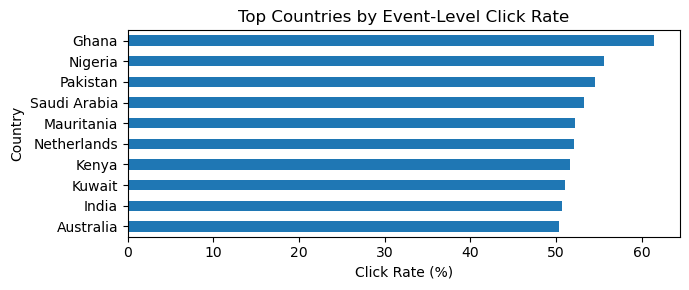

In [36]:
plt.figure(figsize=(7, 3))

country_engagement['click_rate'].sort_values().plot(
    kind='barh'
)

plt.title('Top Countries by Event-Level Click Rate')
plt.xlabel('Click Rate (%)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [37]:
artist_metrics = pd.crosstab(
    df['artist'],
    df['event']
)

artist_metrics['click_rate'] = (
    artist_metrics['click'] /
    artist_metrics['pageview'].replace(0, np.nan)
)

In [38]:
artist_metrics['click_rate'] *= 100

In [39]:
artist_engagement = artist_metrics[
    artist_metrics['pageview'] >= 50
].sort_values(
    'click_rate',
    ascending=False
).head(10)

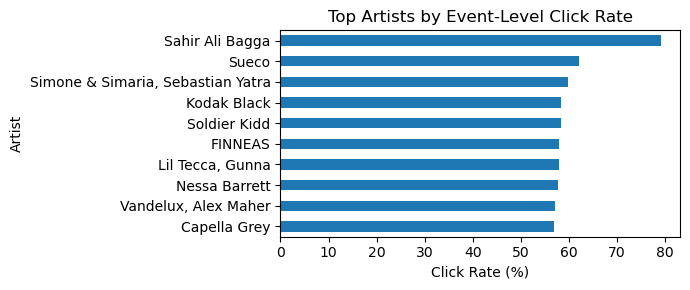

In [41]:
plt.figure(figsize=(7, 3))

artist_engagement['click_rate'].sort_values().plot(
    kind='barh'
)

plt.title('Top Artists by Event-Level Click Rate')
plt.xlabel('Click Rate (%)')
plt.ylabel('Artist')

plt.tight_layout()
plt.show()

In [42]:
link_metrics = pd.crosstab(
    df['linkid'],
    df['event']
)

link_metrics['click_rate'] = (
    link_metrics['click'] /
    link_metrics['pageview'].replace(0, np.nan)
) * 100

link_engagement = link_metrics[
    link_metrics['pageview'] >= 20
].sort_values(
    'click_rate',
    ascending=False
).head(10)

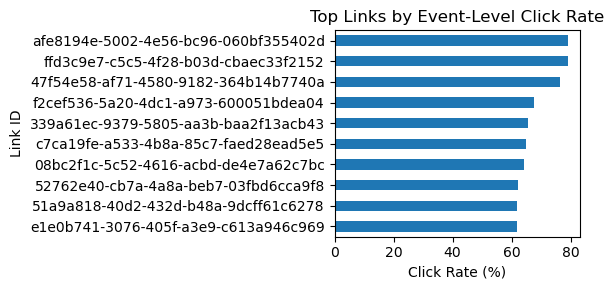

In [44]:
plt.figure(figsize=(6,3))

link_engagement['click_rate'].sort_values().plot(
    kind='barh'
)

plt.title('Top Links by Event-Level Click Rate')
plt.xlabel('Click Rate (%)')
plt.ylabel('Link ID')

plt.tight_layout()
plt.show()

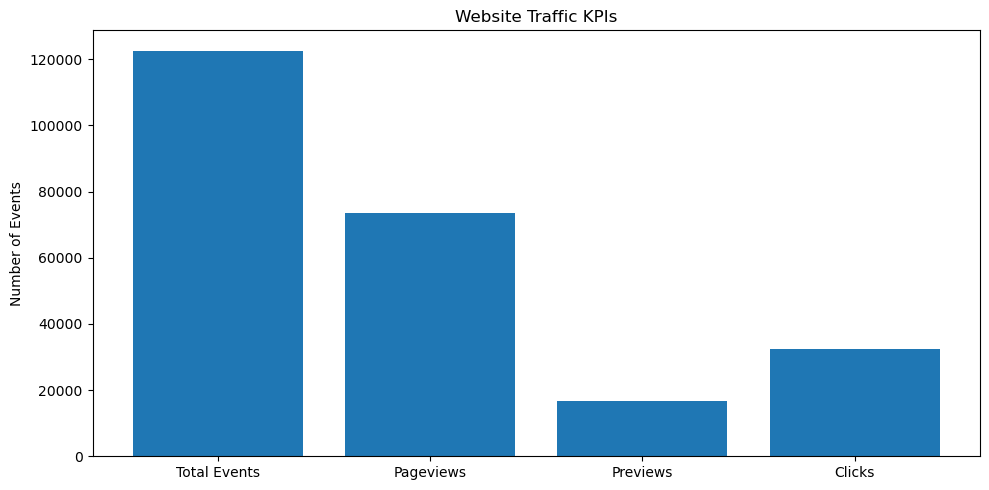

In [45]:
kpi_values = [
    total_events,
    pageviews,
    previews,
    clicks
]

kpi_names = [
    'Total Events',
    'Pageviews',
    'Previews',
    'Clicks'
]

plt.figure(figsize=(10, 5))

plt.bar(kpi_names, kpi_values)

plt.title('Website Traffic KPIs')
plt.ylabel('Number of Events')

plt.tight_layout()
plt.show()

In [46]:
journey_summary = pd.DataFrame({
    'Stage': [
        'Pageview',
        'Preview',
        'Click'
    ],
    'Events': [
        pageviews,
        previews,
        clicks
    ]
})

journey_summary

,Stage,Events
0,Pageview,73360
1,Preview,16708
2,Click,32499


In [47]:
traffic_summary = pd.DataFrame({
    'Metric': [
        'Total Events',
        'Pageviews',
        'Previews',
        'Clicks',
        'Pageview → Click Rate',
        'Pageview → Preview Rate',
        'Countries',
        'Cities',
        'Artists',
        'Tracks',
        'Links'
    ],
    'Value': [
        total_events,
        pageviews,
        previews,
        clicks,
        f"{pageview_click_rate:.2f}%",
        f"{pageview_preview_rate:.2f}%",
        df['country'].nunique(),
        df['city'].nunique(),
        df['artist'].nunique(),
        df['track'].nunique(),
        df['linkid'].nunique()
    ]
})

traffic_summary

,Metric,Value
0,Total Events,122567
1,Pageviews,73360
2,Previews,16708
3,Clicks,32499
4,Pageview → Click Rate,44.30%
5,Pageview → Preview Rate,22.78%
6,Countries,211
7,Cities,11993
8,Artists,2419
9,Tracks,3562


In [48]:
traffic_summary.to_csv(
    'traffic_summary.csv',
    index=False
)

daily_event.to_csv(
    'daily_event_analysis.csv'
)

country_event_top.to_csv(
    'country_event_analysis.csv'
)

artist_engagement.to_csv(
    'artist_engagement.csv'
)

link_engagement.to_csv(
    'link_engagement.csv'
)

print("Phase 3 analysis files saved successfully!")

Phase 3 analysis files saved successfully!
